In [1]:
import jax 
import jax.numpy as jnp
from jax.scipy.stats import gamma

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

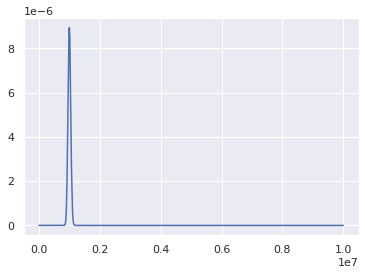

In [2]:
# What does the prior look like?
n_samples = 1000
s_target = 1e-6

alpha = n_samples / 2
beta = n_samples / 2 * s_target

x = jnp.linspace(0, 10 * 1 / s_target, 1e6)
plt.plot(x, gamma.pdf(x, a=alpha, scale=1/beta), '-') # scipy uses k/theta parametrization instead of alpha/beta

(1e-07, 0.001)

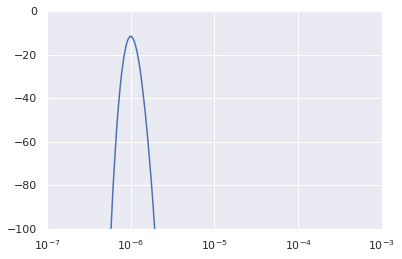

In [3]:
# Now plot it in terms of variance and log
plt.plot(1 / x, gamma.logpdf(x, a=alpha, scale=1/beta), '-')
plt.xscale('log')
plt.ylim([-100, 0])
plt.xlim([s_target / 10, 1e-3])

In [8]:
from jax import jit, numpy as jnp, random

from modax.training.convergence import Convergence
from modax.training.sparsity_scheduler import mask_scheduler
from modax.training.logging import Logger
from flax.core import freeze
from modax.training.utils import create_stateful_update
from sklearn.model_selection import train_test_split
from modax.training.utils import validation_metric

In [5]:
# Custom train function which always runs until max_its

def train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn,
    val_fn,
    mask_update_fn,
    X,
    y,
    max_epochs=1e4,
    split=0.2,
    rand_seed=42,
    **loss_fn_kwargs,
):
    # Making test / train
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=rand_seed
    )

    # Creating update functions
    update = create_stateful_update(
        loss_fn, model=model, x=X_train, y=y_train, **loss_fn_kwargs
    )

    logger = Logger()
    scheduler = mask_scheduler(delta=0.0, patience=1000)
    converged = Convergence()

    for epoch in jnp.arange(max_epochs):
        (optimizer, state), train_metrics, output = update(optimizer, state)
        prediction, dt, theta, coeffs = output

        if epoch % 1000 == 0:
            print(f"Loss step {epoch}: {train_metrics['loss']}")

        if epoch % 25 == 0:
            val_metrics = val_fn(
                optimizer,
                state,
                X_test,
                y_test,
                (train_metrics["tau"], train_metrics["nu"]),
            )
            metrics = {**train_metrics, **val_metrics}
            logger.write(metrics, epoch)

            apply_sparsity, optimizer = scheduler(
                metrics["val_mse"], epoch, optimizer
            )  # we need to find the minimum neg LL of the mse

            if apply_sparsity:
                mask = mask_update_fn(theta, dt)
                state = freeze({"vars": {"MaskedLeastSquares_0": {"mask": mask}}})

        #if converged(epoch, coeffs):
        #    mask = mask_update_fn(theta, dt)
        #    print(f"Converged at epoch {epoch} with mask {mask[:, None]}.")
        #    break

    logger.close()
    return optimizer, state

In [6]:
# %% Imports
from modax.data.burgers import burgers
from modax.models import DeepmodBayes
from modax.linear_model.mask_estimator import ThresholdedLasso
from modax.losses.bayesian import loss_fn_pinn_bayes_typeII
from flax import optim

In [9]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-3, 4, 50)
t = jnp.linspace(0.5, 5.0, 20)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")
u = burgers(x_grid, t_grid, 0.1, 1.0)

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.50 * jnp.std(y) * random.normal(key, y.shape)

In [10]:
val_fn = jit(lambda opt, state, X, y, args: validation_metric(params=opt.target, state=state, model=model, x=X, y=y, prior_params_mse=prior_params_mse, prior_params_reg=prior_params_reg, train_params=args))

In [11]:
# Setting priors
n_samples = X.shape[0]
prior_params_reg = (n_samples/2, n_samples/2 * 1e-6)
prior_params_mse = (0.0, 0.0)

In [12]:
model = DeepmodBayes([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

mask_fn = ThresholdedLasso(threshold=0.1)

In [13]:
optimizer, state = train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn_pinn_bayes_typeII,
    val_fn,
    mask_fn,
    X,
    y,
    max_epochs=50000,
    split=0.8,
    rand_seed=42,
    prior_params_reg = prior_params_reg,
    prior_params_mse = prior_params_mse
)

Loss step 0: -4713.18798828125
Loss step 1000: -7725.84814453125
Loss step 2000: -7770.22412109375
Loss step 3000: -7773.7509765625
Loss step 4000: -7775.5439453125
Loss step 5000: -7776.55029296875
Loss step 6000: -7777.43505859375
Loss step 7000: -7777.77001953125
Loss step 8000: -7777.6083984375
Loss step 9000: -7777.89453125
Loss step 10000: -7778.21484375
Loss step 11000: -7764.47265625
Loss step 12000: -7775.2177734375
Loss step 13000: -7776.427734375
Loss step 14000: -7776.66064453125
Loss step 15000: -7777.25
Loss step 16000: -7776.61376953125
Loss step 17000: -7776.9404296875
Loss step 18000: -7777.71630859375
Loss step 19000: -7777.60400390625
Loss step 20000: -7777.58740234375
Loss step 21000: -7777.29052734375
Loss step 22000: -7777.92041015625
Loss step 23000: -7777.88623046875
Loss step 24000: -7777.84619140625
Loss step 25000: -7777.69970703125
Loss step 26000: -7777.93505859375
Loss step 27000: -7777.5302734375
Loss step 28000: -7777.544921875
Loss step 29000: -7777.722

In [14]:
variables = {"params": optimizer.target, **state}
prediction = model.apply(variables, X, mutable=list(state.keys()))[0][0].reshape(x_grid.shape)

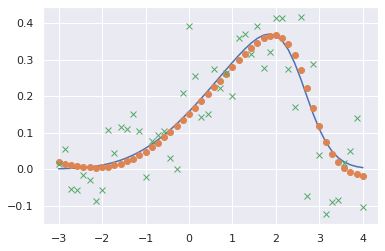

In [15]:
frame = 20
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [16]:
1 / n_samples * jnp.linalg.norm(u - prediction)**2

DeviceArray(0.00048623, dtype=float32)

In [17]:
state

FrozenDict({
    vars: {
        MaskedLeastSquares_0: {
            mask: DeviceArray([False, False,  True, False, False,  True, False, False,
                         False,  True, False, False], dtype=bool),
        },
    },
})